<a href="https://colab.research.google.com/github/abarbierif/IA_UBB/blob/Project/CNN_CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# `CNN CIFAR-10`
En este notebook se extrae el vector de características de un subconjunto de datos de `CIFAR-10` usando `ResNet50`. Todos los vectores de características obtenidos son clasificados con `MLP` y `RFC`.

### `Librerias`

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import sys
import pandas as pd
import pickle
import time
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications import resnet50
from tensorflow.keras.preprocessing.image import smart_resize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.initializers import GlorotUniform, Zeros
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import Accuracy, F1Score

os.chdir('/content/drive/MyDrive/AI/Project')
sys.path.append('/content/drive/MyDrive/AI/Project/py_utils')

from data_loading import *
from data_visualization import *
from utils import *
from data_preprocessing import *

#reproducibility (deterministic)
from tensorflow.keras.utils import set_random_seed
#from tensorflow.config.experimental import enable_op_determinism

set_random_seed(1)
#enable_op_determinism()

os.getcwd()

'/content/drive/MyDrive/AI/Project'

In [ ]:
os.listdir('./')

['results',
 'py_utils',
 'feature_vectors',
 'weights',
 'CNN_FashionMNIST.ipynb',
 'keypointsCIFAR10.pdf',
 'SIFT_FashionMNIST.ipynb',
 'SIFT_CIFAR10.ipynb',
 'CNN_CIFAR10.ipynb']

### `Cargar Dataset`

In [ ]:
X, y = load_data(
    source='tfds',
    to='ndarray',
    dataset='cifar10',
    dims=(32,32)
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/50000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.IEQH52_3.0.2/cifar10-train.tfrecord*...:   0%|         …

Generating test examples...:   0%|          | 0/10000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.IEQH52_3.0.2/cifar10-test.tfrecord*...:   0%|          …

Dataset cifar10 downloaded and prepared to /root/tensorflow_datasets/cifar10/3.0.2. Subsequent calls will reuse this data.


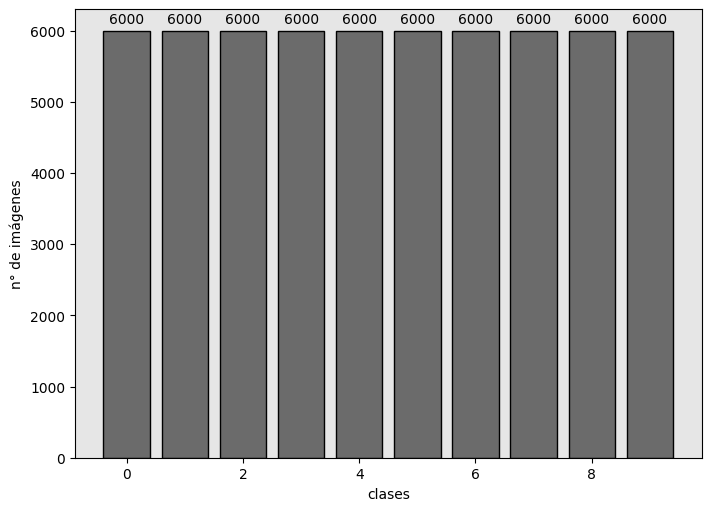

In [ ]:
classes_distribution(
    y,
    figsize=(7,5),
    title='',
    hatch='',
    cmap=None,
    xlabel='clases',
    ylabel='n° de imágenes',
    labelrotation=0,
    facecolor='#e6e6e6',
    color='#6b6b6b'
)

### `Funciones`

In [ ]:
def testing_data(X, Y, samples_per_class):

    '''
    Esta función selecciona un subconjunto balanceado de datos de un conjunto de datos mayor, asegurando que haya un número igual de muestras para cada clase.

    Los datos seleccionados se utilizan para fines de prueba o evaluación, y la función también imprime la forma de los datos resultantes y un gráfico de la distribución de clases.

    Parámetros:
        X: Conjunto de imágenes o datos (ndarray).
        Y: Etiquetas correspondientes a las imágenes o datos (ndarray).
        samples_per_class: Número de muestras a seleccionar por cada clase.

    Retorna:
        X: Subconjunto de datos seleccionados (ndarray).
        Y: Etiquetas correspondientes al subconjunto de datos (ndarray).
    '''

    if samples_per_class > np.max(np.unique(Y, return_counts=True)[1]):
        raise ValueError(f"samples_per_class must be less than {np.max(np.unique(Y, return_counts=True)[1])}")

    for _ in np.unique(Y):
        X = np.delete(X, np.argwhere(Y == _)[samples_per_class:], axis=0)
        Y = np.delete(Y, np.argwhere(Y == _)[samples_per_class:], axis=0)

    print(f"X shape: {X.shape}, Y shape: {Y.shape}")
    classes_distribution(Y, figsize=(7,5), title='', hatch='', cmap=None, xlabel='clases', ylabel='n° de imágenes', labelrotation=0, facecolor='#e6e6e6', color='#6b6b6b')

    return X, Y

In [ ]:
def train_predict(x=None, y=None, classifier=None, classes=None, weights_path=None, write_file=None):

    '''
    Esta función entrena un clasificador ('rfc' o 'mlp') utilizando validación cruzada estratificada con 5 folds
    y evalúa su rendimiento en términos de precisión (accuracy) y F1-score ponderado.

    Los resultados de cada fold y las medias se almacenan en un DataFrame y, opcionalmente, se guardan en un archivo.

    Parámetros:
        x: Vectores de características (ndarray).
        y: Etiquetas (ndarray).
        classifier: Tipo de clasificador a utilizar ('rfc' para RandomForestClassifier o 'mlp' para un perceptrón multicapa).
        classes: Número de clases (requerido para 'mlp').
        weights_path: Ruta para guardar los pesos del modelo 'mlp' (opcional).
        write_file: Ruta para guardar el DataFrame con los resultados (opcional).

    Retorna:
        None. (Los resultados se almacenan en un DataFrame y se guardan en un archivo si se especifica 'write_file'.)

    '''

    if classifier not in ['rfc', 'mlp']:
        raise ValueError("classifier must be 'rfc' or 'mlp'")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
    df = pd.DataFrame(columns=['','accuracy', 'f1_weighted'])

    for n, (train_idx, test_idx) in enumerate(skf.split(x, y)):

        if classifier == 'rfc':
            clf = RandomForestClassifier(n_estimators=500, random_state=42)
            clf.fit(x[train_idx], y[train_idx])

            y_pred = clf.predict(x[test_idx])
            accuracy = accuracy_score(y[test_idx], y_pred)
            f1 = f1_score(y[test_idx], y_pred, average='weighted')

            df.loc[len(df)] = ['',accuracy, f1]

        elif classifier == 'mlp':

            dimdin = x.shape[1]

            clf = Sequential()
            clf.add(Dense(256, input_dim=dimdin, activation='relu', kernel_initializer=GlorotUniform(seed=1), bias_initializer=Zeros()))
            clf.add(BatchNormalization())
            clf.add(Dropout(0.5, seed=1))
            clf.add(Dense(classes, activation='softmax', kernel_initializer=GlorotUniform(seed=1), bias_initializer=Zeros()))

            optimizer_adam = Adam(learning_rate=0.001)
            SC = EarlyStopping(monitor='val_loss', patience=10, verbose=1)
            MCP = ModelCheckpoint(filepath=weights_path+f"_iteration{n}.keras", save_best_only=True, verbose=0)

            clf.compile(
                optimizer=optimizer_adam,
                loss='categorical_crossentropy',
                metrics=['accuracy', F1Score(average='weighted')]
            )

            fit_hist = clf.fit(
                x=x[train_idx],
                y=preprocess_data(preprocess='onehot_encoding', labels_ndarray=y[train_idx]),
                epochs=50,
                batch_size=32,
                validation_split=0.2,
                verbose=1,
                callbacks=[SC,MCP],
                shuffle=True
            )

            score = clf.evaluate(x=x[test_idx], y=preprocess_data(preprocess='onehot_encoding', labels_ndarray=y[test_idx]), verbose=1)

            df.loc[len(df)] = ['', score[1], score[2]]


        del clf

    df.loc[len(df)] = ['means', df['accuracy'].mean(), df['f1_weighted'].mean()]

    #write dataframe
    if write_file != None:
        with open(write_file, 'wb') as file:
            pickle.dump(df, file)

In [ ]:
def cnn_feature_extractor(X, y, extractor=None, weights_path=None, feature_vectors_path=None):

    '''
    Esta función extrae vectores de características de un conjunto de datos utilizando un extractor CNN preentrenado.

    Si el extractor no es entrenable, se utiliza directamente para predecir los vectores de características.
    Si el extractor es entrenable, se realiza una validación cruzada estratificada con 5 folds para encontrar los mejores pesos del modelo,
    y luego se utiliza el extractor con los mejores pesos para predecir los vectores de características.

    Los vectores de características resultantes se guardan en un archivo.

    Parámetros:
        X: Conjunto de imágenes o datos (ndarray).
        y: Etiquetas correspondientes a las imágenes o datos (ndarray).
        extractor: Modelo de extractor CNN (por ejemplo, ResNet50).
        weights_path: Ruta para guardar los pesos del modelo (opcional, solo para extractores entrenables).
        feature_vectors_path: Ruta para guardar los vectores de características extraídos.

    Retorna:
        cnn_feature_vectors: Vectores de características extraídos (ndarray).
    '''

    if extractor.trainable == False:

        cnn_feature_vectors = extractor.predict(X)

    else:

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
        best_weights_dict = {}

        for n, (train_idx, test_idx) in enumerate(skf.split(X, y)):

            weight_path =  weights_path+f"_iteration{n}.keras"

            model = Sequential()
            model.add(extractor)
            model.add(Dense(10, activation='softmax', kernel_initializer=GlorotUniform(seed=1), bias_initializer=Zeros()))

            optimizer_adam = Adam(learning_rate=0.001)
            SC = EarlyStopping(monitor='val_loss', patience=10, verbose=1)
            MCP = ModelCheckpoint(filepath=weights_path+f"_iteration{n}.keras", save_best_only=True, verbose=0)

            model.compile(
                optimizer=optimizer_adam,
                loss='categorical_crossentropy',
                metrics=['accuracy', F1Score(average='weighted')]
            )

            fit_hist = model.fit(
                x=X[train_idx],
                y=preprocess_data(preprocess='onehot_encoding', labels_ndarray=y[train_idx]),
                epochs=50,
                batch_size=32,
                validation_split=0.2,
                verbose=1,
                callbacks=[SC, MCP],
                shuffle=True
            )

            score = model.evaluate(x=X[test_idx], y=preprocess_data(preprocess='onehot_encoding', labels_ndarray=y[test_idx]), verbose=1)
            best_weights_dict[weight_path] = np.mean([score[1], score[2]])

            del model
            del optimizer_adam
            del SC
            del MCP

        model = Sequential()
        model.add(extractor)
        model.add(Dense(10, activation='softmax', kernel_initializer=GlorotUniform(seed=1), bias_initializer=Zeros()))

        best_weights = max(best_weights_dict, key=best_weights_dict.get)
        model.load_weights(best_weights)
        #model.summary()

        extractor = Model(inputs=extractor.input, outputs=model.layers[-2].output)
        #extractor.summary()
        cnn_feature_vectors = extractor.predict(X)

        del model, extractor

    np.save(feature_vectors_path, cnn_feature_vectors)
    return cnn_feature_vectors

### `Preprocesamiento`

X shape: (5000, 32, 32, 3), Y shape: (5000,)


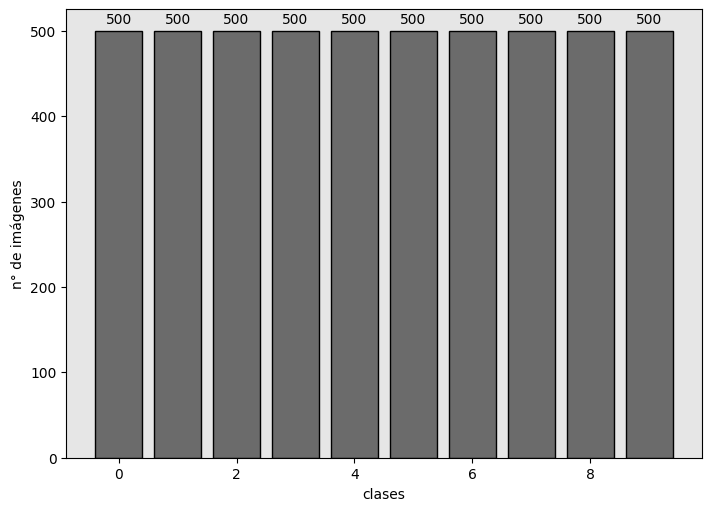

In [ ]:
#selección de un subconjunto de los datos
X, y = testing_data(X, y, samples_per_class=500)

In [ ]:
#redimensionamiento de las imágenes (32, 32) -> (224, 224)
X = np.array([smart_resize(img, (224, 224)) for img in X])
#preprocesamiento para ResNet50
X = resnet50.preprocess_input(X)

print(f"X shape: {X.shape}, Y shape: {y.shape}")

X shape: (5000, 224, 224, 3), Y shape: (5000,)


### `CNN feature extractor`

In [ ]:
ResNet50NonTrainable = ResNet50(
    include_top=False,
    weights="imagenet",
    input_tensor=None,
    input_shape=(224, 224, 3),
    pooling='avg',
    classes=10,
    classifier_activation="softmax",
    name="",
)

ResNet50NonTrainable.trainable = False
ResNet50NonTrainable.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: ""

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
start_time = time.time()
cnn_feature_vectors_ResNet50NonTrainable = cnn_feature_extractor(
    X,
    y,
    extractor=ResNet50NonTrainable,
    weights_path='weights/ResNet50NonTrainable',
    feature_vectors_path='feature_vectors/resnet50nontrainable.npy'
)

print(f"cnn_feature_vectors_ResNet50NonTrainable shape: {cnn_feature_vectors_ResNet50NonTrainable.shape}")
end_time = time.time()
print(f"Tiempo de ejecución: {end_time - start_time} segundos")

157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 97ms/step
cnn_feature_vectors_ResNet50NonTrainable shape: (5000, 2048)
Tiempo de ejecución: 30.681055545806885 segundos


In [ ]:
ResNet50Trainable = ResNet50(
    include_top=False,
    weights="imagenet",
    input_tensor=None,
    input_shape=(224, 224, 3),
    pooling='avg',
    classes=10,
    classifier_activation="softmax",
    name="",
)

for layer in ResNet50Trainable.layers[:-37]:
    layer.trainable = False

ResNet50Trainable.summary()

Model: ""

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)             

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 15,241,216 (58.14 MB)

 Non-trainable params: 8,346,496 (31.84 MB)

In [ ]:
start_time = time.time()
cnn_feature_vectors_ResNet50Trainable = cnn_feature_extractor(
    X,
    y,
    extractor=ResNet50Trainable,
    weights_path='weights/ResNet50Trainable',
    feature_vectors_path='feature_vectors/resnet50trainable.npy'
)

print(f"cnn_feature_vectors_ResNet50Trainable shape: {cnn_feature_vectors_ResNet50Trainable.shape}")
end_time = time.time()
print(f"Tiempo de ejecución: {end_time - start_time} segundos")

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 39s 205ms/step - accuracy: 0.6688 - f1_score: 0.6679 - loss: 1.1353 - val_accuracy: 0.4812 - val_f1_score: 0.4320 - val_loss: 11.1415
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 149ms/step - accuracy: 0.9187 - f1_score: 0.9185 - loss: 0.2580 - val_accuracy: 0.8225 - val_f1_score: 0.8253 - val_loss: 0.7304
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 139ms/step - accuracy: 0.9725 - f1_score: 0.9725 - loss: 0.1028 - val_accuracy: 0.7625 - val_f1_score: 0.7804 - val_loss: 1.2034
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 153ms/step - accuracy: 0.9819 - f1_score: 0.9819 - loss: 0.0623 - val_accuracy: 0.8163 - val_f1_score: 0.8188 - val_loss: 0.7216
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 154ms/step - accuracy: 0.9836 - f1_score: 0.9836 - loss: 0.0496 - val_accuracy: 0.8450 - val_f1_score: 0.8468 - val_loss: 0.5169
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 155ms/step - accuracy: 0.9973 - f1_score: 0.9973 - loss: 0.0153 - val_accuracy: 0.8788 - v

### `Clasificación`

#### `MLP NonTrainable`

In [ ]:
train_predict(
    x=cnn_feature_vectors_ResNet50NonTrainable,
    y=y,
    classifier='mlp',
    classes=10,
    weights_path='weights/ResNet50NonTrainable',
    write_file='results/ResNet50NonTrainable.pkl'
)

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6229 - f1_score: 0.6223 - loss: 1.2438 - val_accuracy: 0.8400 - val_f1_score: 0.8388 - val_loss: 0.4854
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8653 - f1_score: 0.8651 - loss: 0.3999 - val_accuracy: 0.8712 - val_f1_score: 0.8707 - val_loss: 0.4001
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9049 - f1_score: 0.9048 - loss: 0.2955 - val_accuracy: 0.8737 - val_f1_score: 0.8744 - val_loss: 0.3653
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9259 - f1_score: 0.9259 - loss: 0.2199 - val_accuracy: 0.8700 - val_f1_score: 0.8708 - val_loss: 0.3738
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9418 - f1_score: 0.9417 - loss: 0.1790 - val_accuracy: 0.8788 - val_f1_score: 0.8795 - val_loss: 0.3735
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9565 - f1_score: 0.9567 - loss: 0.1359 - val_accuracy: 0.8763 - val_f1_score: 0.8765 - val_los

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.6204 - f1_score: 0.6182 - loss: 1.2294 - val_accuracy: 0.8100 - val_f1_score: 0.8141 - val_loss: 0.6010
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8793 - f1_score: 0.8791 - loss: 0.3422 - val_accuracy: 0.8612 - val_f1_score: 0.8615 - val_loss: 0.4364
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9109 - f1_score: 0.9106 - loss: 0.2542 - val_accuracy: 0.8550 - val_f1_score: 0.8558 - val_loss: 0.4261
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9461 - f1_score: 0.9461 - loss: 0.1799 - val_accuracy: 0.8625 - val_f1_score: 0.8648 - val_loss: 0.4164
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9555 - f1_score: 0.9556 - loss: 0.1311 - val_accuracy: 0.8700 - val_f1_score: 0.8703 - val_loss: 0.4094
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9668 - f1_score: 0.9668 - loss: 0.1103 - val_accuracy: 0.8712 - val_f1_score: 0.8710 - val_los

...

100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.6290 - f1_score: 0.6282 - loss: 1.2137 - val_accuracy: 0.8138 - val_f1_score: 0.8182 - val_loss: 0.5886
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8721 - f1_score: 0.8721 - loss: 0.3907 - val_accuracy: 0.8612 - val_f1_score: 0.8607 - val_loss: 0.4645
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9067 - f1_score: 0.9066 - loss: 0.2662 - val_accuracy: 0.8775 - val_f1_score: 0.8775 - val_loss: 0.3844
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9424 - f1_score: 0.9424 - loss: 0.1831 - val_accuracy: 0.8637 - val_f1_score: 0.8637 - val_loss: 0.3824
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9464 - f1_score: 0.9464 - loss: 0.1616 - val_accuracy: 0.8575 - val_f1_score: 0.8574 - val_loss: 0.4523
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9667 - f1_score: 0.9666 - loss: 0.1227 - val_accuracy: 0.8562 - val_f1_score: 0.8566 - val_los

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.6045 - f1_score: 0.6035 - loss: 1.2839 - val_accuracy: 0.8250 - val_f1_score: 0.8214 - val_loss: 0.5426
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8539 - f1_score: 0.8530 - loss: 0.4158 - val_accuracy: 0.8813 - val_f1_score: 0.8802 - val_loss: 0.3798
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8880 - f1_score: 0.8884 - loss: 0.3117 - val_accuracy: 0.8687 - val_f1_score: 0.8681 - val_loss: 0.4120
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9352 - f1_score: 0.9354 - loss: 0.2062 - val_accuracy: 0.8888 - val_f1_score: 0.8883 - val_loss: 0.3488
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9495 - f1_score: 0.9496 - loss: 0.1562 - val_accuracy: 0.8825 - val_f1_score: 0.8819 - val_loss: 0.3673
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9561 - f1_score: 0.9561 - loss: 0.1363 - val_accuracy: 0.8763 - val_f1_score: 0.8754 - val_los

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6246 - f1_score: 0.6253 - loss: 1.2449 - val_accuracy: 0.8525 - val_f1_score: 0.8512 - val_loss: 0.4848
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8795 - f1_score: 0.8790 - loss: 0.3713 - val_accuracy: 0.8775 - val_f1_score: 0.8777 - val_loss: 0.3824
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9174 - f1_score: 0.9172 - loss: 0.2636 - val_accuracy: 0.8700 - val_f1_score: 0.8707 - val_loss: 0.4046
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9381 - f1_score: 0.9380 - loss: 0.2098 - val_accuracy: 0.8675 - val_f1_score: 0.8681 - val_loss: 0.3906
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9531 - f1_score: 0.9531 - loss: 0.1545 - val_accuracy: 0.8700 - val_f1_score: 0.8700 - val_loss: 0.3806
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9647 - f1_score: 0.9646 - loss: 0.1200 - val_accuracy: 0.8763 - val_f1_score: 0.8777 - val_los

In [ ]:
with open('results/ResNet50NonTrainable.pkl', 'rb') as file:
    df_ResNet50NonTrainable = pickle.load(file)

df_ResNet50NonTrainable

,,accuracy,f1_weighted
0,,0.8670,0.867266
1,,0.8650,0.864333
2,,0.8660,0.865861
3,,0.8450,0.843085
4,,0.8690,0.869881
5,means,0.8624,0.862085


#### `MLP Trainable`

In [ ]:
train_predict(
    x=cnn_feature_vectors_ResNet50Trainable,
    y=y,
    classifier='mlp',
    classes=10,
    weights_path='weights/ResNet50Trainable',
    write_file='results/ResNet50Trainable.pkl'
)

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9143 - f1_score: 0.9143 - loss: 0.3472 - val_accuracy: 0.8763 - val_f1_score: 0.8784 - val_loss: 0.4244
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9981 - f1_score: 0.9981 - loss: 0.0140 - val_accuracy: 0.8800 - val_f1_score: 0.8825 - val_loss: 0.4272
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9995 - f1_score: 0.9995 - loss: 0.0070 - val_accuracy: 0.8763 - val_f1_score: 0.8789 - val_loss: 0.4482
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9984 - f1_score: 0.9984 - loss: 0.0112 - val_accuracy: 0.8963 - val_f1_score: 0.8980 - val_loss: 0.4090
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9999 - f1_score: 0.9999 - loss: 0.0027 - val_accuracy: 0.8875 - val_f1_score: 0.8894 - val_loss: 0.4377
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9996 - f1_score: 0.9996 - loss: 0.0036 - val_accuracy: 0.8875 - val_f1_score: 0.8893 - val_loss

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9067 - f1_score: 0.9062 - loss: 0.3300 - val_accuracy: 0.8700 - val_f1_score: 0.8715 - val_loss: 0.4888
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9993 - f1_score: 0.9993 - loss: 0.0084 - val_accuracy: 0.8562 - val_f1_score: 0.8576 - val_loss: 0.5084
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9988 - f1_score: 0.9988 - loss: 0.0053 - val_accuracy: 0.8600 - val_f1_score: 0.8611 - val_loss: 0.5272
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9997 - f1_score: 0.9997 - loss: 0.0031 - val_accuracy: 0.8712 - val_f1_score: 0.8726 - val_loss: 0.5206
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9999 - f1_score: 0.9999 - loss: 0.0024 - val_accuracy: 0.8650 - val_f1_score: 0.8668 - val_loss: 0.5203
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - f1_score: 1.0000 - loss: 0.0013 - val_accuracy: 0.8650 - val_f1_score: 0.8670 - val_loss

...

100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9043 - f1_score: 0.9046 - loss: 0.3733 - val_accuracy: 0.8737 - val_f1_score: 0.8746 - val_loss: 0.4504
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9998 - f1_score: 0.9998 - loss: 0.0068 - val_accuracy: 0.8700 - val_f1_score: 0.8717 - val_loss: 0.4795
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - f1_score: 1.0000 - loss: 0.0038 - val_accuracy: 0.8725 - val_f1_score: 0.8744 - val_loss: 0.4844
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - f1_score: 1.0000 - loss: 0.0017 - val_accuracy: 0.8750 - val_f1_score: 0.8766 - val_loss: 0.4929
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - f1_score: 1.0000 - loss: 9.9794e-04 - val_accuracy: 0.8775 - val_f1_score: 0.8795 - val_loss: 0.5067
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - f1_score: 1.0000 - loss: 8.0028e-04 - val_accuracy: 0.8737 - val_f1_score: 0.8758 - 

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8916 - f1_score: 0.8928 - loss: 0.3871 - val_accuracy: 0.8825 - val_f1_score: 0.8833 - val_loss: 0.4441
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9990 - f1_score: 0.9990 - loss: 0.0113 - val_accuracy: 0.8763 - val_f1_score: 0.8773 - val_loss: 0.4570
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - f1_score: 1.0000 - loss: 0.0067 - val_accuracy: 0.8775 - val_f1_score: 0.8785 - val_loss: 0.4594
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9996 - f1_score: 0.9996 - loss: 0.0040 - val_accuracy: 0.8838 - val_f1_score: 0.8851 - val_loss: 0.4796
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9994 - f1_score: 0.9994 - loss: 0.0041 - val_accuracy: 0.8712 - val_f1_score: 0.8730 - val_loss: 0.5054
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - f1_score: 1.0000 - loss: 0.0032 - val_accuracy: 0.8825 - val_f1_score: 0.8839 - val_loss

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8911 - f1_score: 0.8916 - loss: 0.3989 - val_accuracy: 0.8737 - val_f1_score: 0.8742 - val_loss: 0.4336
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9967 - f1_score: 0.9967 - loss: 0.0146 - val_accuracy: 0.8813 - val_f1_score: 0.8826 - val_loss: 0.4497
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - f1_score: 1.0000 - loss: 0.0057 - val_accuracy: 0.8888 - val_f1_score: 0.8899 - val_loss: 0.4526
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - f1_score: 1.0000 - loss: 0.0036 - val_accuracy: 0.8850 - val_f1_score: 0.8860 - val_loss: 0.4680
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9997 - f1_score: 0.9997 - loss: 0.0031 - val_accuracy: 0.8850 - val_f1_score: 0.8859 - val_loss: 0.4880
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - f1_score: 1.0000 - loss: 0.0020 - val_accuracy: 0.8863 - val_f1_score: 0.8874 - val_loss

In [ ]:
with open('results/ResNet50Trainable.pkl', 'rb') as file:
    df_ResNet50Trainable = pickle.load(file)

df_ResNet50Trainable

,,accuracy,f1_weighted
0,,0.9680,0.967990
1,,0.9820,0.981998
2,,0.9760,0.975969
3,,0.9770,0.977056
4,,0.9750,0.974978
5,means,0.9756,0.975598


#### `RFC NonTrainable`

In [ ]:
train_predict(
    x=cnn_feature_vectors_ResNet50NonTrainable,
    y=y,
    classifier='rfc',
    classes=None,
    weights_path=None,
    write_file='results/ResNet50NonTrainableRFC.pkl'
)

In [ ]:
with open('results/ResNet50NonTrainableRFC.pkl', 'rb') as file:
    df_ResNet50NonTrainableRFC = pickle.load(file)

df_ResNet50NonTrainableRFC

,,accuracy,f1_weighted
0,,0.8360,0.835680
1,,0.8530,0.852999
2,,0.8560,0.854713
3,,0.8410,0.840297
4,,0.8470,0.846168
5,means,0.8466,0.845971


#### `RFC Trainable`

In [ ]:
train_predict(
    x=cnn_feature_vectors_ResNet50Trainable,
    y=y,
    classifier='rfc',
    classes=None,
    weights_path=None,
    write_file='results/ResNet50TrainableRFC.pkl'
)

In [ ]:
with open('results/ResNet50TrainableRFC.pkl', 'rb') as file:
    df_ResNet50TrainableRFC = pickle.load(file)

df_ResNet50TrainableRFC

,,accuracy,f1_weighted
0,,0.9710,0.971030
1,,0.9760,0.976004
2,,0.9690,0.968904
3,,0.9730,0.973065
4,,0.9680,0.967990
5,means,0.9714,0.971399
